## 1. Data Loading


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load Data.
data = load_breast_cancer()
pd.set_option('display.max_columns', None)
df = pd.DataFrame(data.data, columns = data.feature_names)
df['target'] = data.target

## 2. EDA

In [11]:
print(df.shape)
print(df.describe())
print(df.isnull().sum())
print(df['target'].value_counts())

(569, 31)
       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.000000   

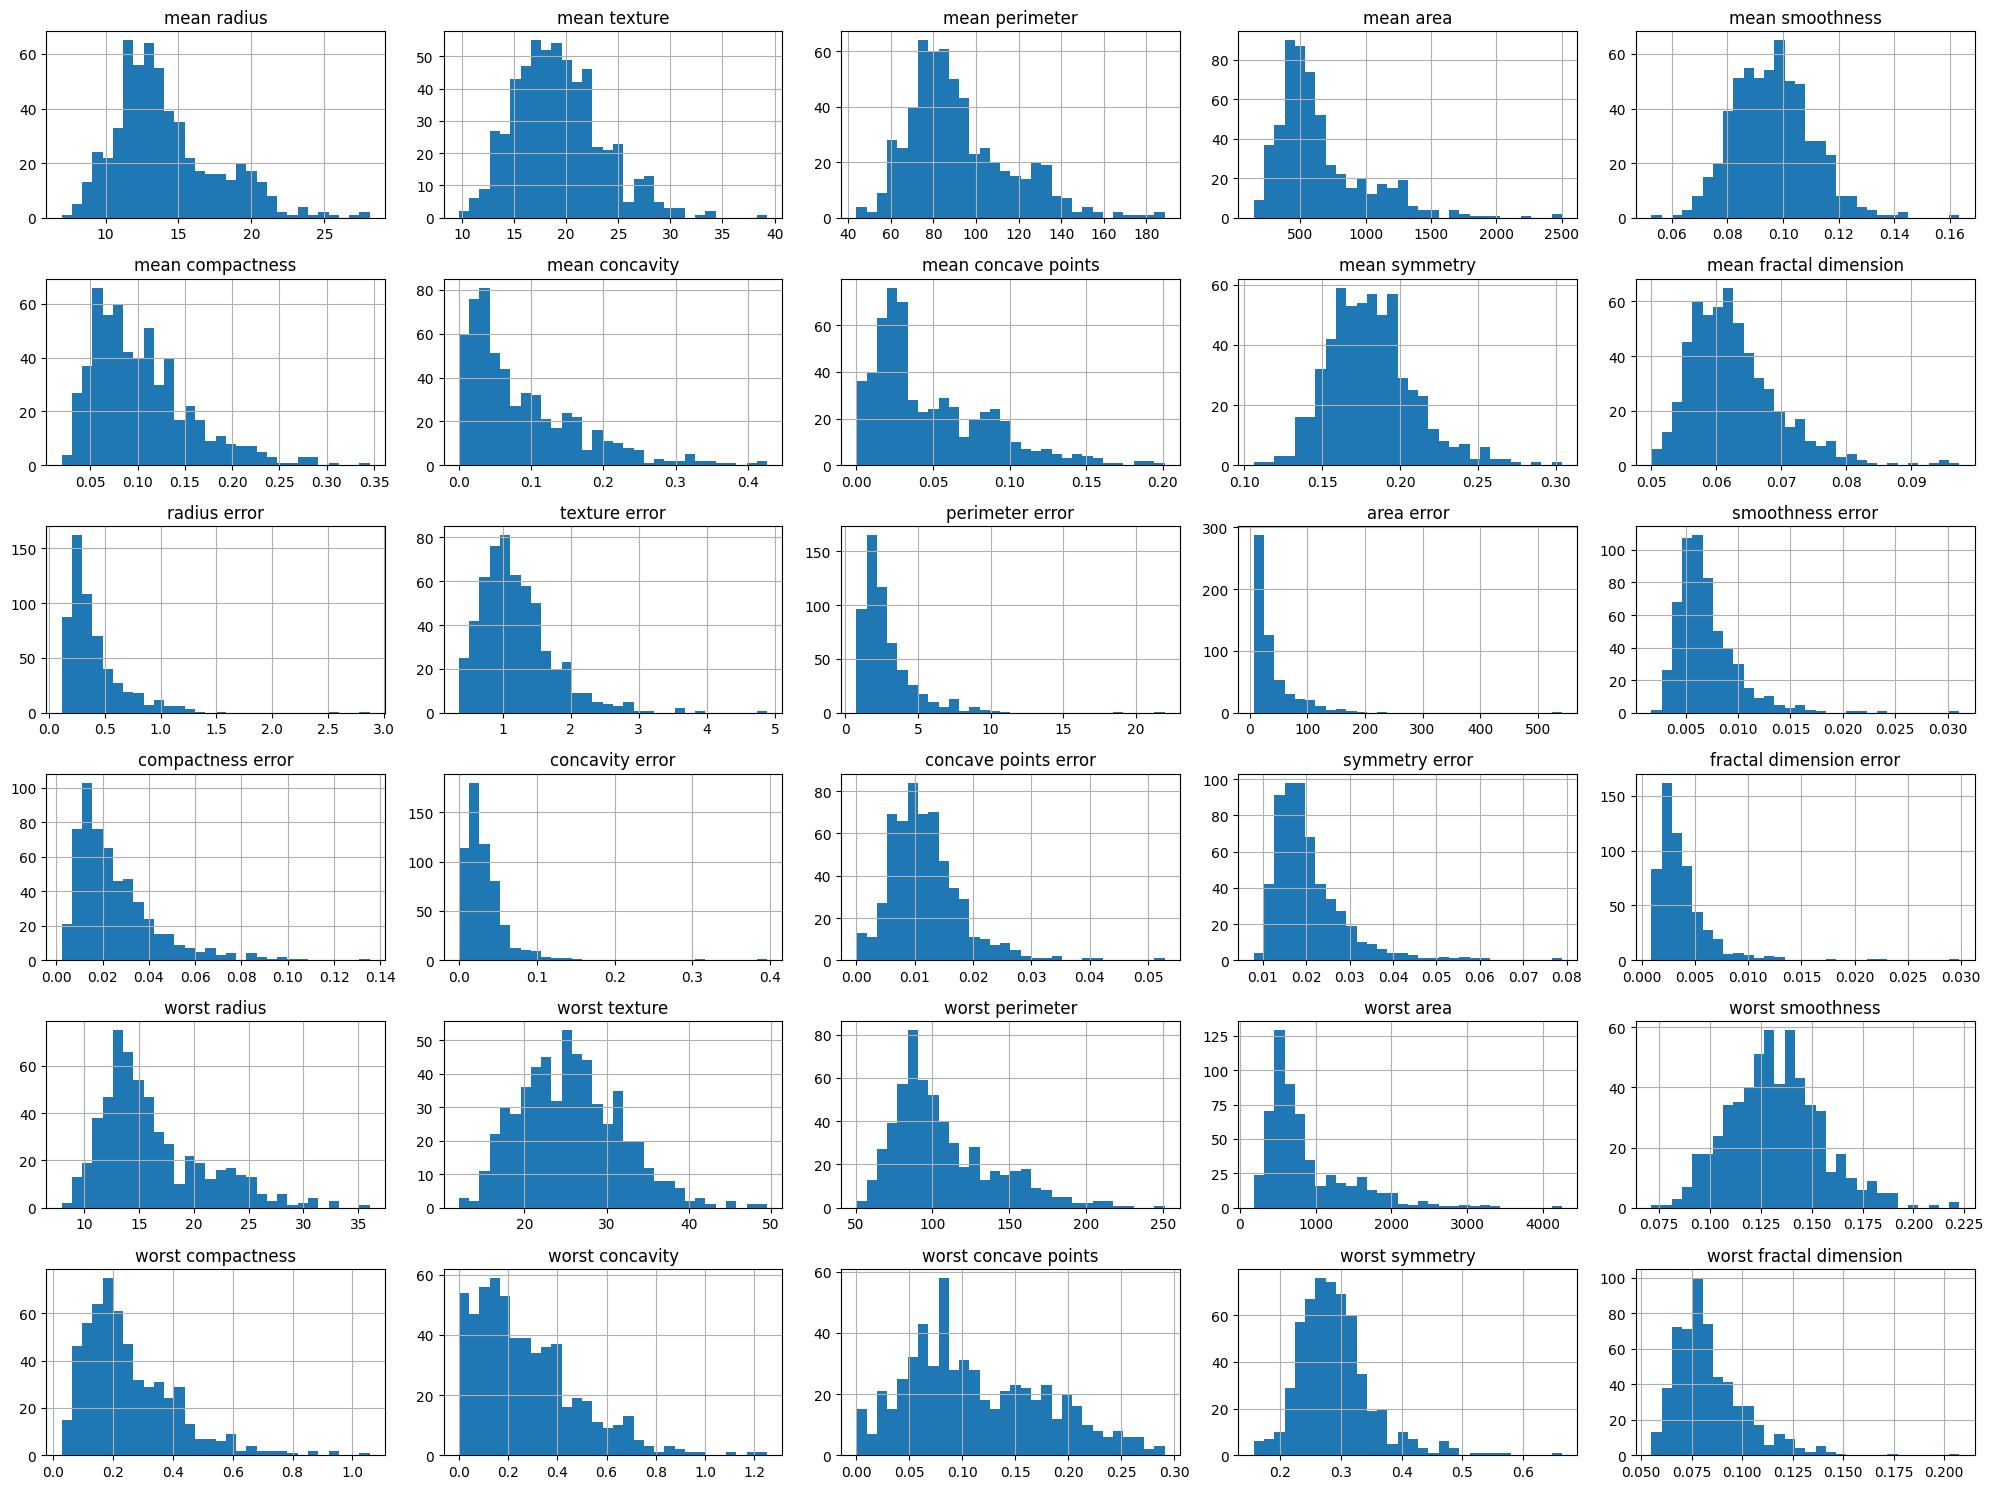

In [12]:
df.drop('target', axis=1).hist(bins=30, figsize=(20,15))
plt.tight_layout()
plt.show()

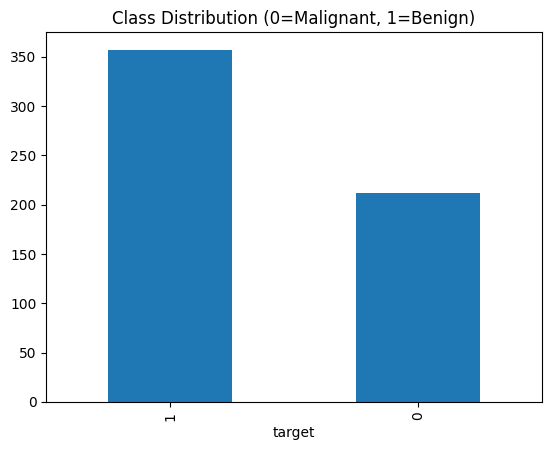

In [13]:
df['target'].value_counts().plot(kind='bar')
plt.title('Class Distribution (0=Malignant, 1=Benign)')
plt.show()

In [16]:
# cap the skewed columns
skewed_cols = [
    'radius error',
    'perimeter error',
    'area error',
    'smoothness error',
    'compactness error',
    'concavity error',
    'concave points error',
    'fractal dimension error',
    'worst area',
    'worst compactness',
    'worst concavity',
]
for col in skewed_cols:
  cap = df[col].quantile(0.99)
  df[col] = df[col].clip(upper=cap)

# check mean vs median after capping
for col in skewed_cols:
  print(f"{col}: mean={df[col].mean():.3f}, median={df[col].median():.3f}")

radius error: mean=0.400, median=0.324
perimeter error: mean=2.825, median=2.287
area error: mean=38.863, median=24.530
smoothness error: mean=0.007, median=0.006
compactness error: mean=0.025, median=0.020
concavity error: mean=0.031, median=0.026
concave points error: mean=0.012, median=0.011
fractal dimension error: mean=0.004, median=0.003
worst area: mean=875.813, median=686.500
worst compactness: mean=0.253, median=0.212
worst concavity: mean=0.271, median=0.227


In [17]:
df['area error'] = np.log1p(df['area error'])

# Verify
print(f"area error after log: mean={df['area error'].mean():.3f}, median={df['area error'].median():.3f}")

area error after log: mean=3.416, median=3.240


## 3. Data preparation

In [18]:
X = df.drop('target', axis = 1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 4. Logistic From Scratch

Implementing Logistic Regression using only NumPy no sklearn for the model.
Key differences from Linear Regression:
- Output passes through **sigmoid** to produce probabilities (0 to 1)
- Loss function is **Binary Cross Entropy** instead of MSE
- Gradients have identical structure only forward pass changes

In [20]:
class LogisticRegression:
  def __init__(self, lr = 0.01, num_iter = 1000):
    self.lr = lr
    self.num_iter = num_iter
    self.weights = np.array([])
    self.bias = 0
    self.loss_history = []

  def sigmoid(self, z):
    return 1 / (1 + np.exp(-z))

  def fit(self, X, y):
    self.weights = np.zeros(X.shape[1])
    self.bias = 0.0
    n_samples = X.shape[0]
    for _ in range(self.num_iter):
      y_pred = np.dot(X, self.weights) + self.bias
      y_pred = self.sigmoid(y_pred)
      loss = -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
      dW = (1/n_samples) * np.dot(X.T, (y_pred - y))
      db = (1/n_samples) * np.sum(y_pred - y)
      self.weights -= self.lr * dW
      self.bias -= self.lr * db
      self.loss_history.append(loss)

  def predict(self, X):
    y_pred = np.dot(X, self.weights) + self.bias
    y_pred = self.sigmoid(y_pred)
    return (y_pred >= 0.5).astype(int)

In [28]:
model = LogisticRegression(lr = 0.01, num_iter = 10000)
model.fit(X_train, y_train)
preds = model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report
print(accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

0.9736842105263158
              precision    recall  f1-score   support

           0       0.95      0.98      0.96        42
           1       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



## 5. Compare against sklearn
## Results Comparison

| Iterations | Accuracy | Malignant Recall | Malignant F1 |
|------------|----------|-----------------|--------------|
| 1,000 | 95.6% | 0.95 | 0.94 |
| 10,000 | 97.4% | 0.98 | 0.96 |
| Sklearn | 98.2% | 0.98 | 0.98 |

Gap explained: gradient descent vs LBFGS optimizer.
More iterations consistently close the gap.

In [27]:
from sklearn.linear_model import LogisticRegression as SklearnLR

sklearn = SklearnLR(max_iter = 10000)
sklearn.fit(X_train, y_train)
sk_preds = sklearn.predict(X_test)

print(accuracy_score(y_test, sk_preds))
print(classification_report(y_test, sk_preds))

0.9824561403508771
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## 6. Evaluation Metrics

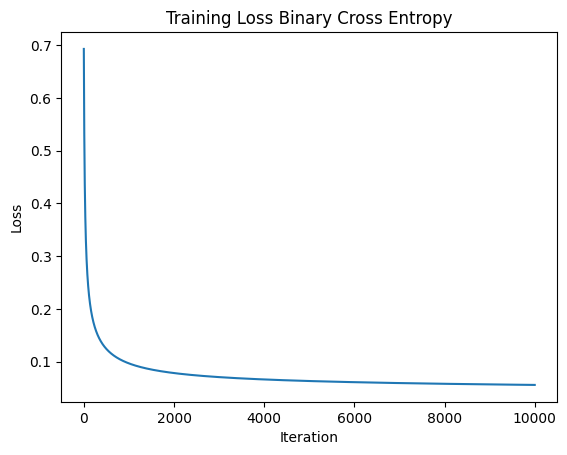

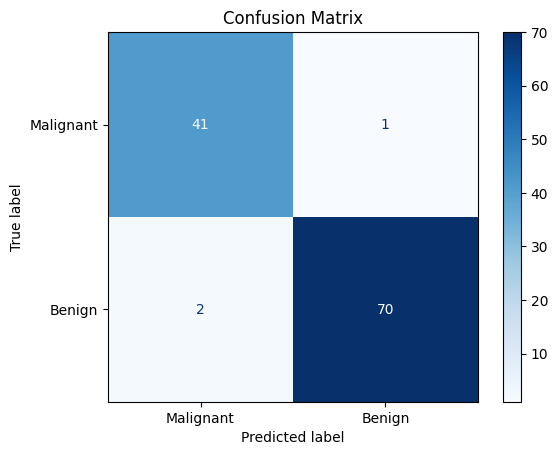

In [30]:
# Loss curve
plt.plot(model.loss_history)
plt.title('Training Loss Binary Cross Entropy')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.show()

# Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Malignant','Benign'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

### Confusion Matrix Analysis
- **41/42 malignant tumors caught** missed only 1
- **2 false alarms** out of 72 benign cases
- Recall on malignant class = 0.98 critical for medical diagnosis
- Missing a malignant tumor (FN) is far more dangerous than a false alarm (FP)

# Logistic Regression from Scratch Results & Analysis

### What I Built
Implemented Logistic Regression using gradient descent with only NumPy.
No sklearn used for the model only for verification and data loading.

### How It Works
Logistic Regression extends Linear Regression by passing the output
through a sigmoid function to produce probabilities between 0 and 1.

**Forward pass:**
- z = X·W + b
- ŷ = σ(z) = 1 / (1 + e^(-z))

**Loss Binary Cross Entropy:**
- L = -(1/n) × Σ [y×log(ŷ) + (1-y)×log(1-ŷ)]
- Penalizes confident wrong predictions heavily

**Gradients (derived via chain rule):**
- dW = (1/n) × Xᵀ·(ŷ - y)
- db = (1/n) × Σ(ŷ - y)

**Update:**
- W = W - α·dW
- b = b - α·db

### Dataset
Breast Cancer Wisconsin 569 samples, 30 features.
Binary classification: Malignant (0) vs Benign (1).
Class distribution: 357 benign, 212 malignant (63/37 split).

### Results
| Metric | 1000 iterations | 10000 iterations | Sklearn |
|--------|----------------|-----------------|---------|
| Accuracy | 95.6% | 97.4% | 98.2% |
| Recall (Malignant) | 0.95 | 0.98 | 0.98 |
| F1 (Malignant) | 0.94 | 0.96 | 0.98 |

### Confusion Matrix (10000 iterations)
- Caught 41 out of 42 malignant tumors missed only 1
- 2 false alarms out of 72 benign cases

### Why Results Differ from Sklearn
My implementation uses basic gradient descent. Sklearn uses LBFGS
a more sophisticated optimizer that converges faster and more precisely.
More iterations close the gap: 1000 iter → 95.6%, 10000 iter → 97.4%.

### Why Recall Matters More Than Accuracy Here
Missing a malignant tumor (False Negative) means a patient goes
untreated life threatening. A false alarm (False Positive) means
an unnecessary follow-up test costly but not dangerous. For medical
diagnosis, recall on the malignant class is the critical metric.

### Key Learnings
- Sigmoid squashes any value to 0-1, enabling probability output
- Binary cross entropy is convex gradient descent converges reliably
- The gradient formula for logistic regression is identical in structure
  to linear regression only the forward pass changes
- More iterations consistently improve performance until convergence